In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -qr requirements.txt
!pip install -q roboflow

Cloning into 'yolov5'...
remote: Enumerating objects: 17926, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 17926 (delta 70), reused 45 (delta 43), pack-reused 17818 (from 2)
Receiving objects: 100% (17926/17926), 17.08 MiB | 16.06 MiB/s, done.
Resolving deltas: 100% (12201/12201), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.9 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import yaml
from roboflow import Roboflow

print("📥 Mengunduh Dataset 1 (Davin)...")
rf1 = Roboflow(api_key="T4PVnCKUou3nMc10Jf4l")
project1 = rf1.workspace("capstone-g9q9l").project("capstonea4")
dataset1 = project1.version(1).download("yolov5")
path1 = dataset1.location

print("\n📥 Mengunduh Dataset 2 (Zaka)...")
rf2 = Roboflow(api_key="xcatdw5aH8O1J7XOsnxu")
project2 = rf2.workspace("comvis-bdowb").project("capstone-counting-parts-dasgi")
dataset2 = project2.version(1).download("yolov5")
path2 = dataset2.location

print("\n⚙️ Menggabungkan kedua dataset menjadi satu...")
combined_dir = "/content/dataset_gabungan"
for split in ['train', 'valid', 'test']:
    os.makedirs(f"{combined_dir}/{split}/images", exist_ok=True)
    os.makedirs(f"{combined_dir}/{split}/labels", exist_ok=True)

import glob
def merge_data(source_dir, target_dir):
    for split in ['train', 'valid', 'test']:

        for img in glob.glob(f"{source_dir}/{split}/images/*.*"):
            shutil.copy(img, f"{target_dir}/{split}/images/")

        for lbl in glob.glob(f"{source_dir}/{split}/labels/*.txt"):
            shutil.copy(lbl, f"{target_dir}/{split}/labels/")

merge_data(path1, combined_dir)
merge_data(path2, combined_dir)

with open(f"{path1}/data.yaml", 'r') as f:
    yaml_config = yaml.safe_load(f)

new_yaml = {
    'train': f"{combined_dir}/train/images",
    'val': f"{combined_dir}/valid/images",
    'test': f"{combined_dir}/test/images",
    'nc': yaml_config['nc'],
    'names': yaml_config['names']
}

with open(f"{combined_dir}/data.yaml", 'w') as f:
    yaml.dump(new_yaml, f)


total_train = len(os.listdir(f"{combined_dir}/train/images"))
print(f"\n✅ PENGGABUNGAN SUKSES! Total gambar train sekarang: {total_train} gambar")
print(f"Folder gabungan tersimpan di: {combined_dir}")

📥 Mengunduh Dataset 1 (Davin)...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to capstoneA4-1 in yolov5pytorch:: 100%|██████████| 401/401 [00:00<00:00, 8201.67it/s]



📥 Mengunduh Dataset 2 (Zaka)...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to capstone-counting-parts-1 in yolov5pytorch:: 100%|██████████| 209/209 [00:00<00:00, 7577.16it/s]



⚙️ Menggabungkan kedua dataset menjadi satu...

✅ PENGGABUNGAN SUKSES! Total gambar train sekarang: 302 gambar
Folder gabungan tersimpan di: /content/dataset_gabungan


In [ ]:
import yaml

combined_dir = "/content/dataset_gabungan"
yaml_path = f"{combined_dir}/data.yaml"

with open(yaml_path, 'r') as f:
    yaml_config = yaml.safe_load(f)

yaml_config['val'] = f"{combined_dir}/train/images"

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_config, f)

print("File data.yaml berhasil diupdate! Folder 'val' sekarang mengarah ke folder 'train'.")

File data.yaml berhasil diupdate! Folder 'val' sekarang mengarah ke folder 'train'.


In [ ]:
!python train.py \
  --img 640 \
  --batch 16 \
  --epochs 150 \
  --data /content/dataset_gabungan/data.yaml \
  --weights yolov5s.pt \
  --name model_epson_gabungan \
  --cache

Streaming output truncated to the last 5000 lines.
                   all        302       7256      0.956      0.916       0.97       0.57

      Epoch    GPU_mem   box_loss   obj_loss   cls_loss  Instances       Size
  0% 0/19 [00:00<?, ?it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
     34/149      4.32G    0.04437      0.111          0        611        640:   5% 1/19 [00:00<00:03,  4.67it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
     34/149      4.32G    0.04628     0.1138          0        608        640:  11% 2/19 [00:00<00:04,  3.66it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` inste

In [ ]:
!python export.py \
  --weights runs/train/model_epson_gabungan/weights/best.pt \
  --include onnx \
  --img 640 \
  --simplify

export: data=data/coco128.yaml, weights=['runs/train/model_epson_gabungan/weights/best.pt'], imgsz=[640], batch_size=1, device=cpu, half=False, inplace=False, keras=False, optimize=False, int8=False, per_tensor=False, dynamic=False, cache=, simplify=True, mlmodel=False, opset=17, verbose=False, workspace=4, nms=False, agnostic_nms=False, topk_per_class=100, topk_all=100, iou_thres=0.45, conf_thres=0.25, include=['onnx']
YOLOv5 🚀 v7.0-481-g00c14a25 Python-3.12.13 torch-2.10.0+cu128 CPU

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs

PyTorch: starting from runs/train/model_epson_gabungan/weights/best.pt with output shape (1, 25200, 6) (13.7 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxscript'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 200ms
Prepared 3 packages in 1.20s
Installed 3 packages in 293ms
 + onnx==1.21.0
 + onnx-ir==0.2.1
 + onnxscript==0.7.0

requirements

detect: weights=['runs/train/model_epson_gabungan/weights/best.pt'], source=/content/test_baru, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-481-g00c14a25 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
image 1/7 /content/test_baru/springhitam1.jpg: 640x384 24 springs, 49.9ms
image 2/7 /content/test_baru/springhitam2.jpg: 640x384 25 springs, 7.5ms
image 3/7 /content/test_baru/springhitam3.jpg: 640x384 19 springs, 7.4ms
image 4/7 /content/test_baru/springhitam4.jpg: 640x384 17 springs, 7.4ms
image

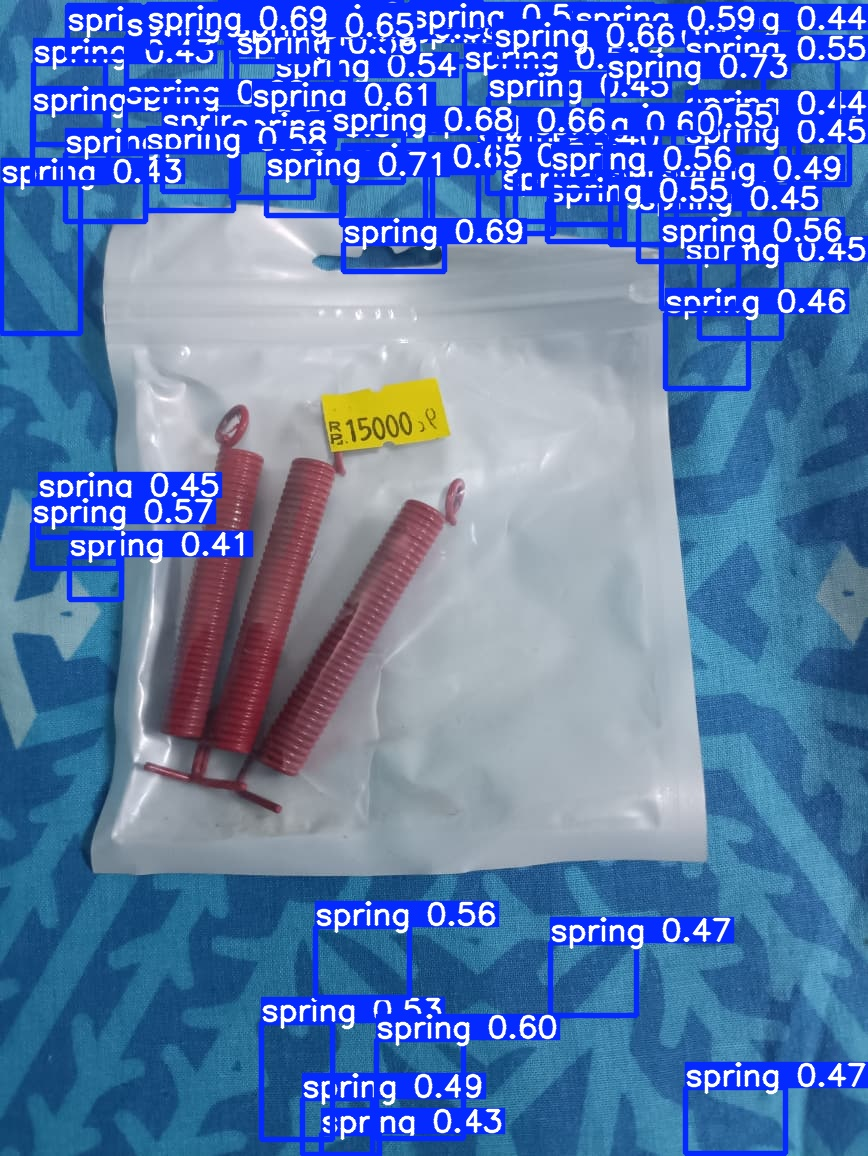

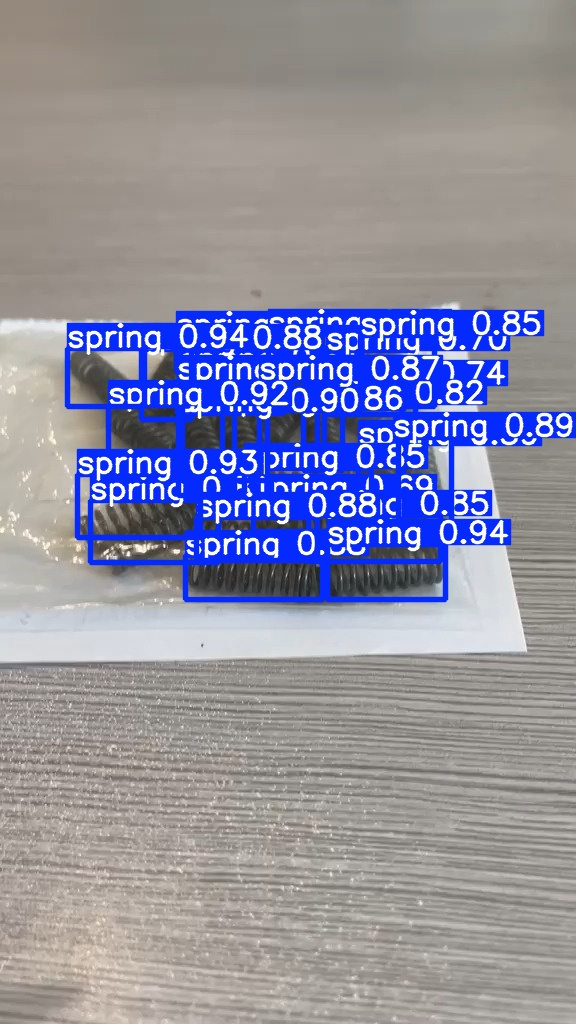

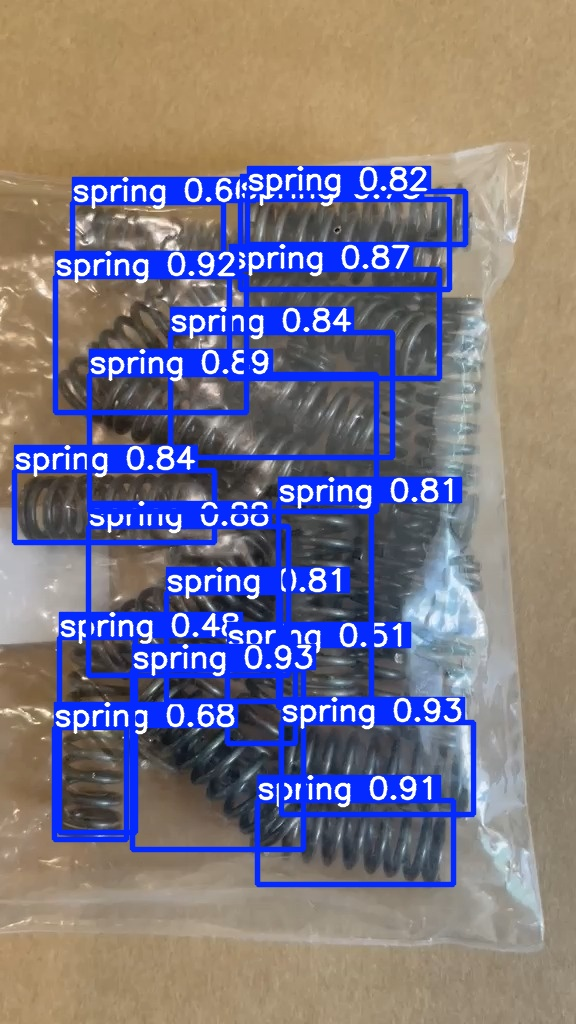

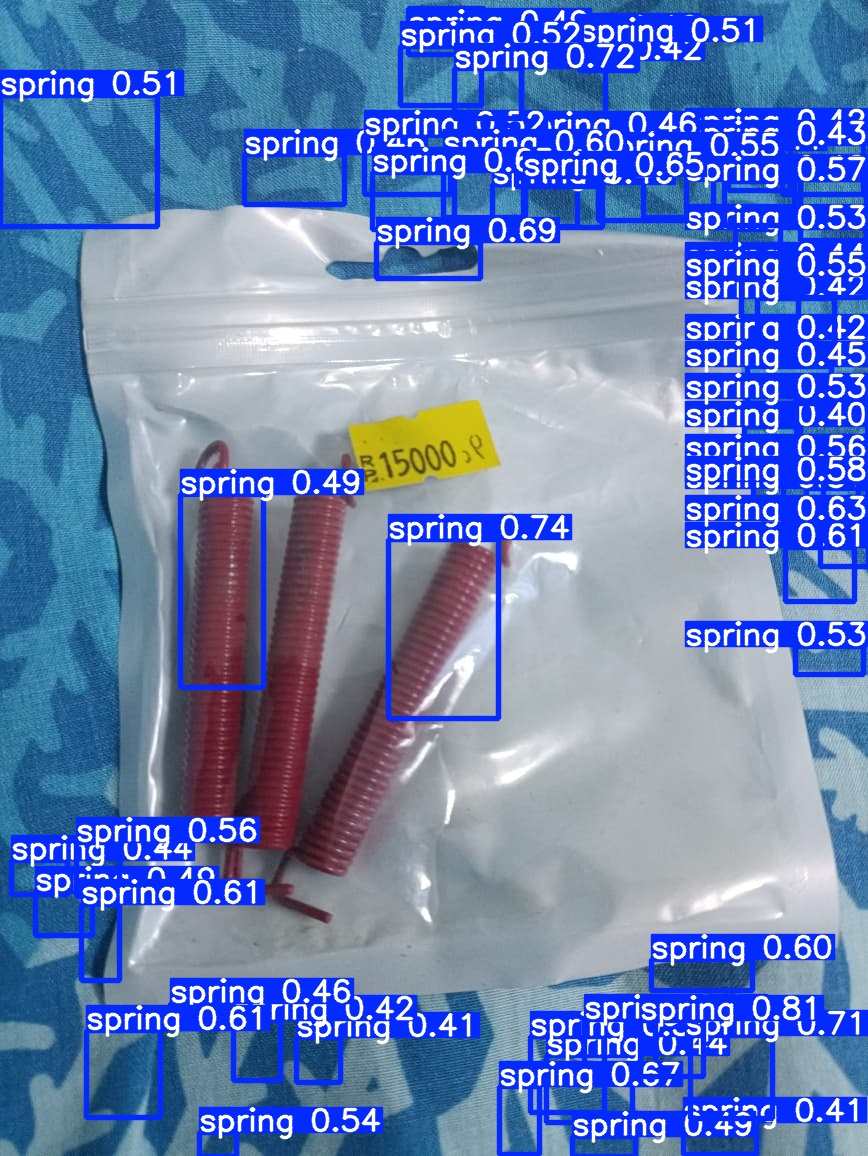

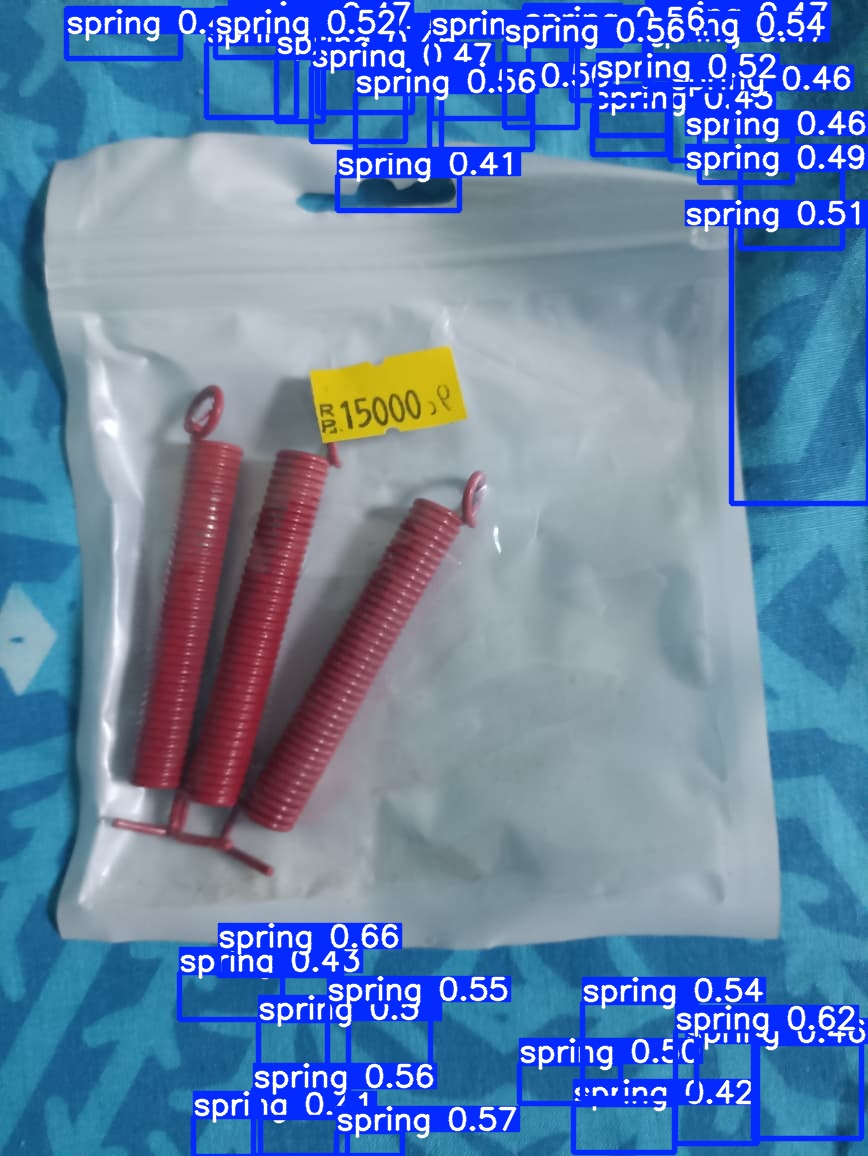

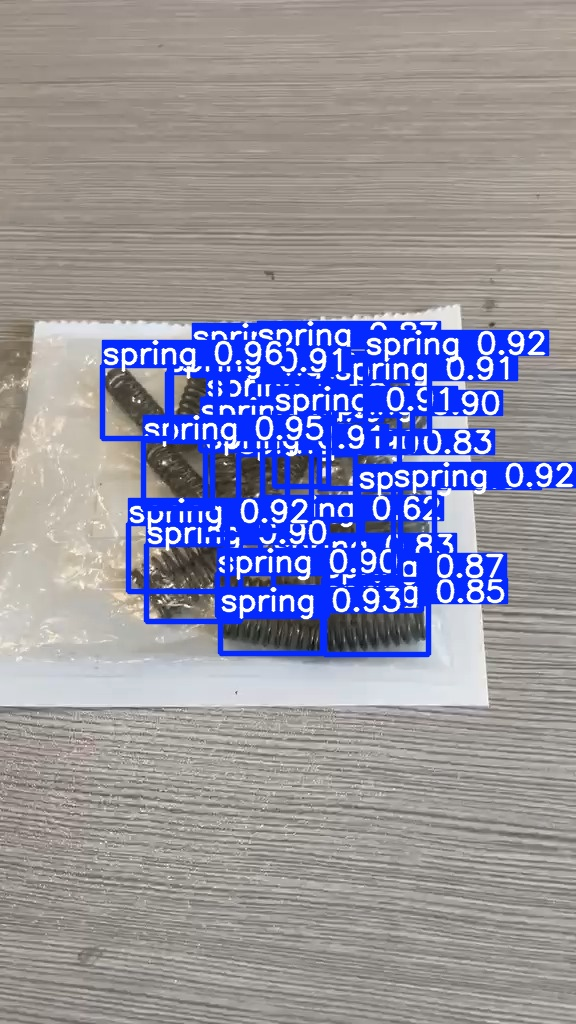

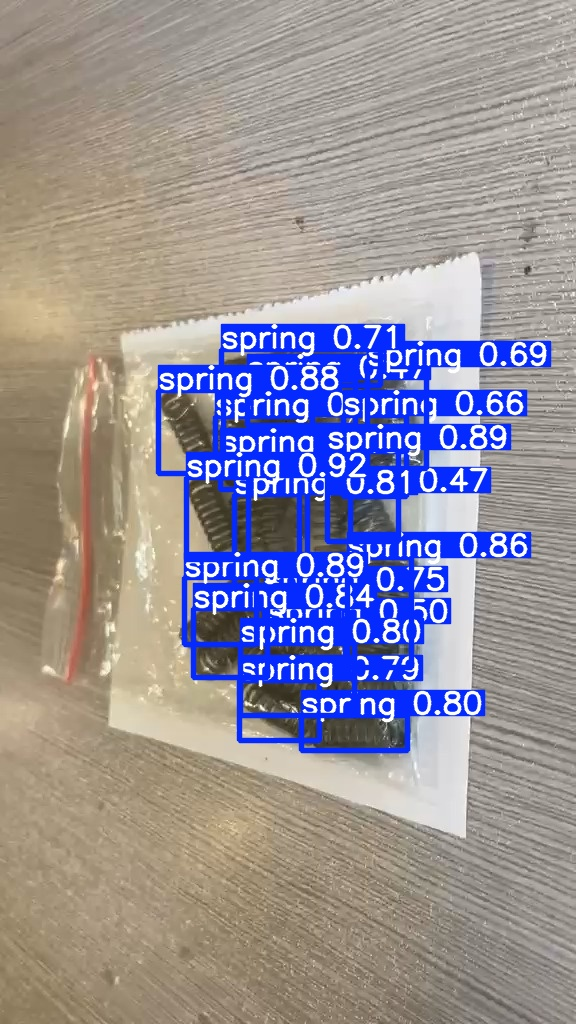

In [ ]:
#testing 1
!python detect.py \
  --weights runs/train/model_epson_gabungan/weights/best.pt \
  --img 640 \
  --conf 0.4 \
  --source /content/test_baru

from IPython.display import Image, display
for imageName in glob.glob('/content/yolov5/runs/detect/exp*/*.jpg'):
    display(Image(filename=imageName))
    print("\n")